# 🏠 Property Recommender System — Final Colab Notebook (V2)

## 1 Install Libraries

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

## 2 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

## 3 Create Output Folders

This ensures all results are saved for thesis and dashboard.

In [3]:
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/data", exist_ok=True)
os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/metrics", exist_ok=True)

## 4 Upload Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

# Upload your London rental dataset CSV.

Saving london_rentals.csv to london_rentals.csv


## 5 Load Dataset

In [5]:
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

,address,subdistrict_code,rent,deposit,Let type,Furnish Type,Coucil Tax,PROPERTY TYPE,BEDROOMS,BATHROOMS,SIZE,avg_distance_to_nearest_station,nearest_station_count
0,"Morse Close, Harefield, UB9",UB9,1200,1384,Long term,Unfurnished,Ask agent,Apartment,1.0,1.0,Ask agent,2.1,3
1,"Dolphin Square, London, SW1V",SW1V,1983,2288,Long term,"Furnished or unfurnished, landlord is flexible",Ask agent,Apartment,1.0,1.0,335 sq ft,0.4,3
2,"Warlters Road, Holloway, London, N7",N7,1800,0,Long term,Unfurnished,Ask agent,Apartment,1.0,1.0,Ask agent,0.5,3
3,"Rockingham Road, Uxbridge",NaN,1650,1903,Long term,Unfurnished,Ask agent,Apartment,2.0,1.0,Ask agent,1.6,3
4,"Northwick Avenue, Harrow, HA3",HA3,2700,3115,Long term,Unfurnished,Ask agent,End of Terrace,3.0,2.0,Ask agent,0.4,3


## 6 Fix Column Names (VERY IMPORTANT)

This prevents the KeyError you encountered.

In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

# Expected columns:
# address
# subdistrict_code
# rent
# deposit
# let_type
# furnish_type
# council_tax
# property_type
# bedrooms
# bathrooms
# size
# avg_distance_to_nearest_station
# nearest_station_count

Index(['address', 'subdistrict_code', 'rent', 'deposit', 'let_type',
       'furnish_type', 'coucil_tax', 'property_type', 'bedrooms', 'bathrooms',
       'size', 'avg_distance_to_nearest_station', 'nearest_station_count'],
      dtype='object')


## 7 Dataset Overview (For Thesis)

In [7]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (3478, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3478 entries, 0 to 3477
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   address                          3478 non-null   object 
 1   subdistrict_code                 1868 non-null   object 
 2   rent                             3478 non-null   int64  
 3   deposit                          3478 non-null   int64  
 4   let_type                         3235 non-null   object 
 5   furnish_type                     3477 non-null   object 
 6   coucil_tax                       3477 non-null   object 
 7   property_type                    3438 non-null   object 
 8   bedrooms                         2841 non-null   float64
 9   bathrooms                        3049 non-null   float64
 10  size                             3478 non-null   object 
 11  avg_distance_to_nearest_station  3478 non-null   float64

,rent,deposit,bedrooms,bathrooms,avg_distance_to_nearest_station,nearest_station_count
count,3478.000000,3478.000000,2841.000000,3049.000000,3478.000000,3478.000000
mean,2593.092582,1789.097757,1.797958,1.431617,0.494940,2.997412
std,2641.117440,2657.305000,0.916597,0.895819,0.361535,0.050811
min,50.000000,0.000000,1.000000,1.000000,0.100000,2.000000
25%,1550.000000,0.000000,1.000000,1.000000,0.300000,3.000000
50%,2275.000000,1038.000000,2.000000,1.000000,0.400000,3.000000
75%,3250.000000,2825.000000,2.000000,2.000000,0.600000,3.000000
max,78000.000000,60000.000000,7.000000,20.000000,10.800000,3.000000


In [8]:
# Save statistics.
df.describe().to_csv("outputs/data/dataset_summary.csv")

## 8 Missing Values Analysis

In [9]:
missing = df.isnull().sum()

print(missing)

missing.to_csv("outputs/data/missing_values.csv")

address                               0
subdistrict_code                   1610
rent                                  0
deposit                               0
let_type                            243
furnish_type                          1
coucil_tax                            1
property_type                        40
bedrooms                            637
bathrooms                           429
size                                  0
avg_distance_to_nearest_station       0
nearest_station_count                 0
dtype: int64


## 9 Handle Missing Values

In [11]:
# --- Fix SIZE column first ---

# Remove "sq ft"
df['size'] = df['size'].str.replace('sq ft', '', regex=False)

# Replace "Ask agent" with NaN
df['size'] = df['size'].replace('Ask agent', np.nan)

# Convert to numeric
df['size'] = pd.to_numeric(df['size'], errors='coerce')


# --- Now handle missing values safely ---

df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())

df['size'] = df['size'].fillna(df['size'].median())

df['furnish_type'] = df['furnish_type'].fillna("Unknown")

df['property_type'] = df['property_type'].fillna("Unknown")


# Verify
print(df.isnull().sum())

address                               0
subdistrict_code                   1610
rent                                  0
deposit                               0
let_type                            243
furnish_type                          0
coucil_tax                            1
property_type                         0
bedrooms                              0
bathrooms                             0
size                                  0
avg_distance_to_nearest_station       0
nearest_station_count                 0
dtype: int64


## 10 Remove Outliers

In [12]:
df = df[df['rent'] < df['rent'].quantile(0.99)]

df = df[df['size'] < df['size'].quantile(0.99)]

## 11 Save Cleaned Dataset

In [13]:
df.to_csv("outputs/data/cleaned_dataset.csv", index=False)

## 12 Data Visualisation (For Thesis Figures)

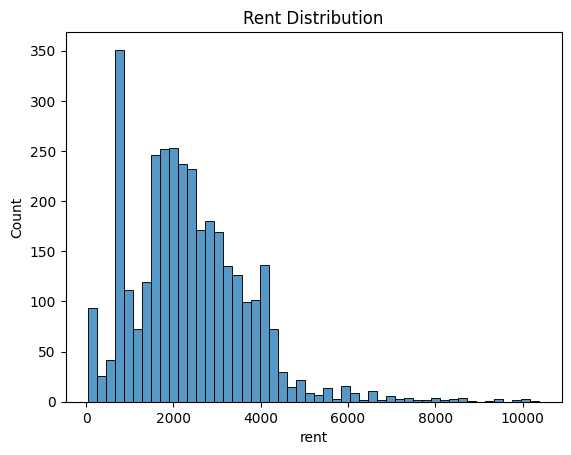

In [14]:
# Rent Distribution
plt.figure()
sns.histplot(df['rent'], bins=50)
plt.title("Rent Distribution")
plt.savefig("outputs/figures/rent_distribution.png")
plt.show()

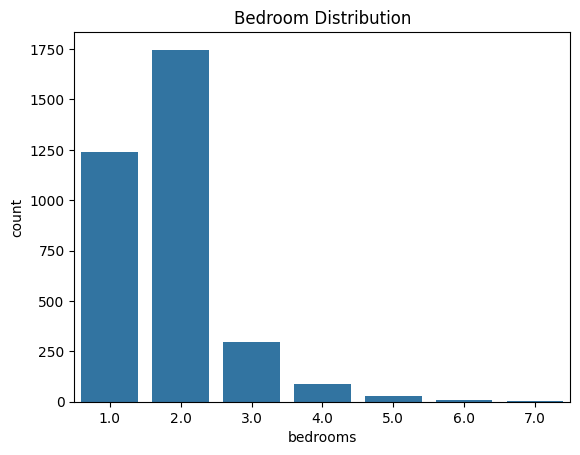

In [15]:
# Bedrooms Distribution
plt.figure()
sns.countplot(x=df['bedrooms'])
plt.title("Bedroom Distribution")
plt.savefig("outputs/figures/bedroom_distribution.png")
plt.show()

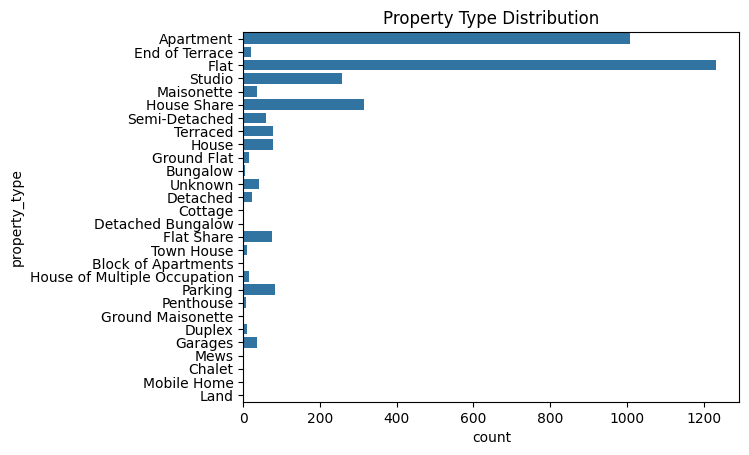

In [16]:
# Property Type Distribution
plt.figure()
sns.countplot(y=df['property_type'])
plt.title("Property Type Distribution")
plt.savefig("outputs/figures/property_type_distribution.png")
plt.show()

## 13 Feature Selection

We select features for the recommender system.

In [17]:
features = [
    "rent",
    "bedrooms",
    "bathrooms",
    "size",
    "avg_distance_to_nearest_station",
    "nearest_station_count"
]

df_features = df[features]

## 14 Feature Scaling

In [18]:
scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(df_features)

scaled_df = pd.DataFrame(scaled_features, columns=features)

# Save scaler.
joblib.dump(scaler, "outputs/models/scaler.pkl")

['outputs/models/scaler.pkl']

## 15 Build Recommendation Model

In [19]:
similarity_matrix = cosine_similarity(scaled_df)

print("Similarity matrix shape:", similarity_matrix.shape)

# Save matrix.
np.save("outputs/models/similarity_matrix.npy", similarity_matrix)

Similarity matrix shape: (3406, 3406)


## 16 Recommendation Function

In [20]:
def recommend_property(index, top_n=5):

    similarity_scores = list(enumerate(similarity_matrix[index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    property_indices = [i[0] for i in similarity_scores]

    return df.iloc[property_indices]

## 17 Example Recommendation

In [21]:
example = recommend_property(10)

example

,address,subdistrict_code,rent,deposit,let_type,furnish_type,coucil_tax,property_type,bedrooms,bathrooms,size,avg_distance_to_nearest_station,nearest_station_count
3184,"Queen's Gate, London, SW7",SW7,3467,4000,Long term,Ask agent,Ask agent,Apartment,2.0,2.0,578.0,0.4,3
3190,"Kensington High Street, Kensington, London, W8",NaN,3467,4000,Long term,Furnished,Ask agent,Flat,2.0,2.0,578.0,0.4,3
3171,"Holland Park Gardens, London, W14",W14,3445,0,Long term,Ask agent,Ask agent,Apartment,2.0,2.0,578.0,0.4,3
3210,"5 Queensberry Place, London",NaN,3553,4100,Long term,Furnished,Ask agent,Flat,2.0,2.0,578.0,0.4,3
851,"Ebury Apartments, Ebury Place, Pimlico SW1",NaN,3467,0,Long term,Furnished,Ask agent,Apartment,2.0,2.0,578.0,0.5,3


In [22]:
# Save example.
example.to_csv("outputs/data/sample_recommendations.csv")

## 18 Baseline Comparison (Simple Filtering)

This simulates MongoDB filtering.

In [23]:
def simple_filter(budget, bedrooms):

    results = df[
        (df['rent'] <= budget) &
        (df['bedrooms'] >= bedrooms)
    ]

    return results.head(5)

# Example:
simple_filter(2000, 2)

,address,subdistrict_code,rent,deposit,let_type,furnish_type,coucil_tax,property_type,bedrooms,bathrooms,size,avg_distance_to_nearest_station,nearest_station_count
3,"Rockingham Road, Uxbridge",NaN,1650,1903,Long term,Unfurnished,Ask agent,Apartment,2.0,1.0,578.0,1.6,3
17,"Uxbridge Road, London, W12",W12,1250,1442,Long term,Furnished,Ask agent,Studio,2.0,1.0,578.0,0.2,3
57,"Jermyn Street, Piccadilly Circus, London, SW1Y",SW1Y,1950,2250,Long term,Furnished,Ask agent,Studio,2.0,1.0,358.0,0.3,3
72,"Dandi Brondesbury, Brondesbury, London, NW2",NW2,1523,1758,Long term,Furnished,Ask agent,Studio,2.0,1.0,100.0,0.5,3
73,"Dandi Brondesbury, Brondesbury, London, NW2",NW2,1472,1699,Long term,Furnished,Ask agent,Studio,2.0,1.0,100.0,0.5,3


## 19 Precision Evaluation

In [24]:
def precision_at_k(index, k=5):

    recs = recommend_property(index, k)

    relevant = recs[
        (recs['rent'] <= df.iloc[index]['rent']) &
        (recs['bedrooms'] >= df.iloc[index]['bedrooms'])
    ]

    return len(relevant) / k

In [25]:
# Evaluate.
precisions = []

for i in range(100):

    precisions.append(precision_at_k(i))

avg_precision = np.mean(precisions)

print("Average Precision:", avg_precision)

# Save metric.
pd.DataFrame({
    "metric": ["precision@5"],
    "value": [avg_precision]
}).to_csv("outputs/metrics/model_metrics.csv")

Average Precision: 0.622


## 20 Diversity Evaluation

In [26]:
def diversity_score(index):

    recs = recommend_property(index)

    return recs['property_type'].nunique()

In [27]:
# Run.
div_scores = []

for i in range(100):

    div_scores.append(diversity_score(i))

avg_diversity = np.mean(div_scores)

print("Average Diversity:", avg_diversity)

# Save.
pd.DataFrame(div_scores).to_csv("outputs/metrics/diversity_scores.csv")

Average Diversity: 2.31


## 21 Fairness / Exposure Analysis

In [28]:
exposure = {}
for i in range(200):

    recs = recommend_property(i)

    for idx in recs.index:

        exposure[idx] = exposure.get(idx, 0) + 1

# Convert.
exposure_df = pd.DataFrame(
    list(exposure.items()),
    columns=["property_id", "exposure_count"]
)

exposure_df.to_csv("outputs/metrics/exposure_analysis.csv")

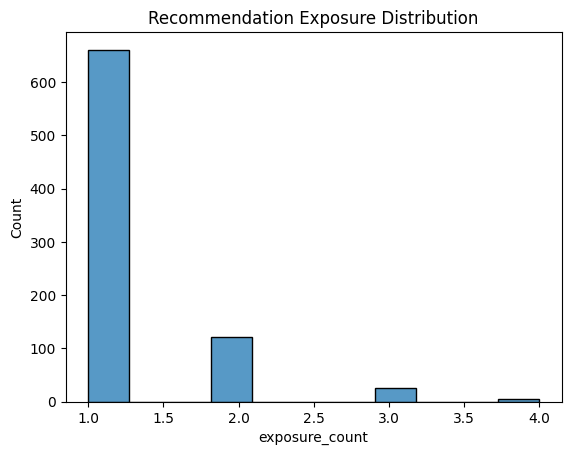

In [29]:
# Plot.
plt.figure()

sns.histplot(exposure_df['exposure_count'])

plt.title("Recommendation Exposure Distribution")

plt.savefig("outputs/figures/exposure_distribution.png")

plt.show()

## 22 Save Model for Backend

In [30]:
model_bundle = {
    "scaler": scaler,
    "similarity_matrix": similarity_matrix,
    "features": features
}

joblib.dump(model_bundle, "outputs/models/recommender_system.pkl")

['outputs/models/recommender_system.pkl']

## 23 Generate Admin Dashboard Statistics

In [31]:
dashboard_stats = {

    "total_properties": len(df),

    "average_rent": df['rent'].mean(),

    "max_rent": df['rent'].max(),

    "min_rent": df['rent'].min(),

    "avg_precision": avg_precision,

    "avg_diversity": avg_diversity
}

pd.DataFrame([dashboard_stats]).to_csv("outputs/data/dashboard_stats.csv")

## 24 Export All Outputs

In [32]:
!zip -r project_outputs.zip outputs

# Download:
files.download("project_outputs.zip")

  adding: outputs/ (stored 0%)
  adding: outputs/data/ (stored 0%)
  adding: outputs/data/sample_recommendations.csv (deflated 55%)
  adding: outputs/data/dataset_summary.csv (deflated 45%)
  adding: outputs/data/dashboard_stats.csv (deflated 19%)
  adding: outputs/data/cleaned_dataset.csv (deflated 83%)
  adding: outputs/data/missing_values.csv (deflated 31%)
  adding: outputs/models/ (stored 0%)
  adding: outputs/models/scaler.pkl (deflated 45%)
  adding: outputs/models/similarity_matrix.npy (deflated 28%)
  adding: outputs/models/recommender_system.pkl (deflated 28%)
  adding: outputs/figures/ (stored 0%)
  adding: outputs/figures/rent_distribution.png (deflated 19%)
  adding: outputs/figures/exposure_distribution.png (deflated 20%)
  adding: outputs/figures/bedroom_distribution.png (deflated 21%)
  adding: outputs/figures/property_type_distribution.png (deflated 15%)
  adding: outputs/metrics/ (stored 0%)
  adding: outputs/metrics/diversity_scores.csv (deflated 59%)
  adding: outpu

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>